<a href="https://colab.research.google.com/github/Shreyasingh1709/Uber-Fare-Prediction/blob/main/Uber_Fare_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all the necessary library. Pandas for Dataframe , Numpy for Numpy-array and matplotlib and seaborn for visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Downloaded the file from Kaggle and loading it in google colab

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving uber.csv to uber.csv


In [ ]:
data = pd.read_csv("uber.csv")
data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
print("Data shape: ",data.shape)
print("*****************************")
print("*****************************")
data.info()
print("*****************************")
print("*****************************")
data.describe()

Data shape:  (200000, 9)
*****************************
*****************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB
*****************************
*****************************


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [ ]:
#checking outlier for each column
describe_data = data.describe()
for i in describe_data:
  if describe_data.loc["max", i] > (describe_data.loc["mean", i] + 3 * describe_data.loc["std", i]):
    print(i,"has outliers")

fare_amount has outliers
pickup_longitude has outliers
pickup_latitude has outliers
dropoff_longitude has outliers
dropoff_latitude has outliers
passenger_count has outliers


In [ ]:
#checking null values in each column
column = data.columns
print(column)
for i in column:
  print("No of null values in ",i,":",data[i].isnull().sum())

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')
No of null values in  Unnamed: 0 : 0
No of null values in  key : 0
No of null values in  fare_amount : 0
No of null values in  pickup_datetime : 0
No of null values in  pickup_longitude : 0
No of null values in  pickup_latitude : 0
No of null values in  dropoff_longitude : 1
No of null values in  dropoff_latitude : 1
No of null values in  passenger_count : 0


In [ ]:
data = pd.read_csv("uber.csv")
data.dropna(subset=['dropoff_longitude','dropoff_latitude'], inplace=True)

In [ ]:
#checking null values in each column
column = data.columns
print(column)
for i in column:
  print("No of null values in ",i,":",data[i].isnull().sum())

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')
No of null values in  Unnamed: 0 : 0
No of null values in  key : 0
No of null values in  fare_amount : 0
No of null values in  pickup_datetime : 0
No of null values in  pickup_longitude : 0
No of null values in  pickup_latitude : 0
No of null values in  dropoff_longitude : 0
No of null values in  dropoff_latitude : 0
No of null values in  passenger_count : 0


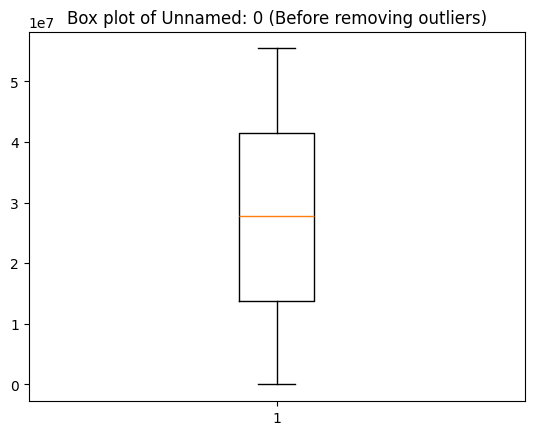

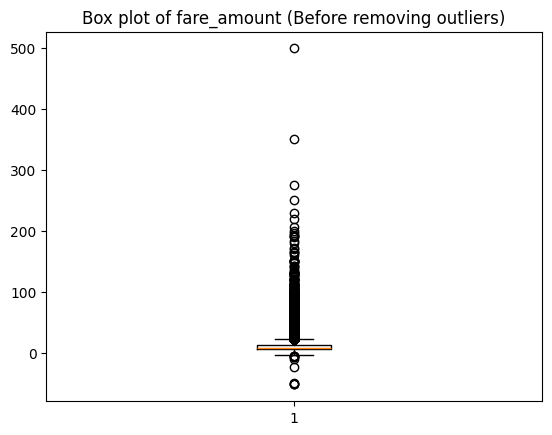

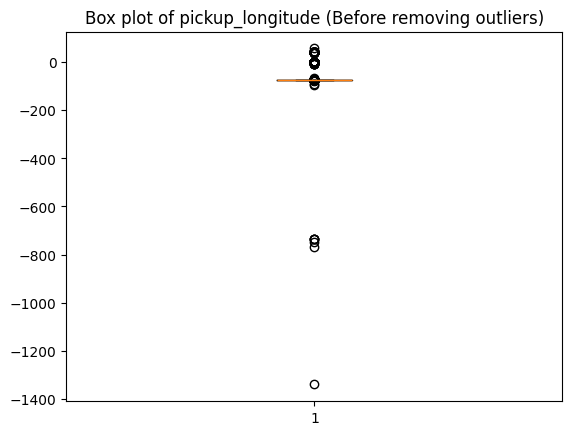

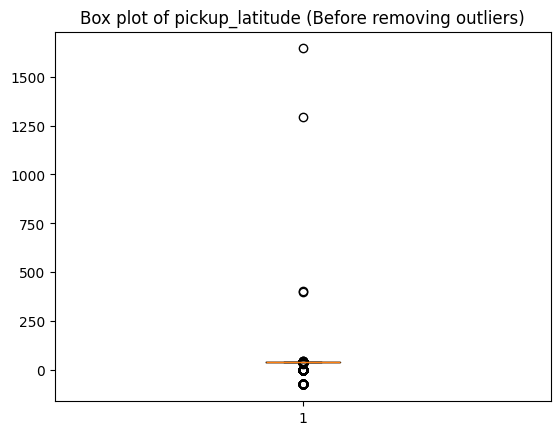

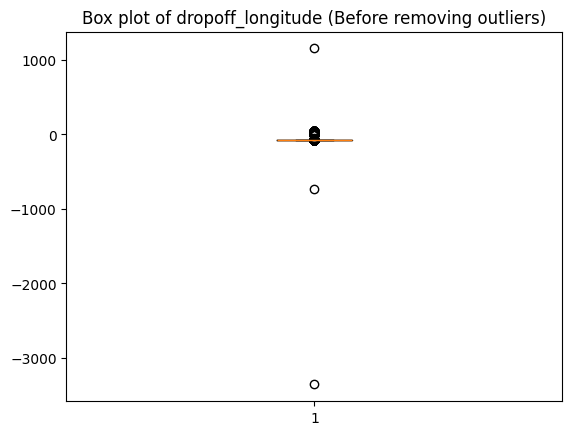

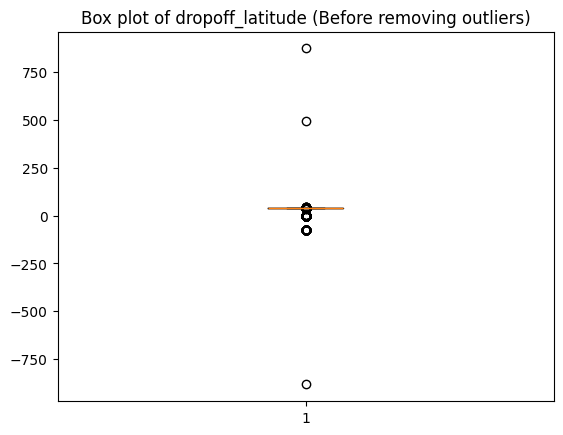

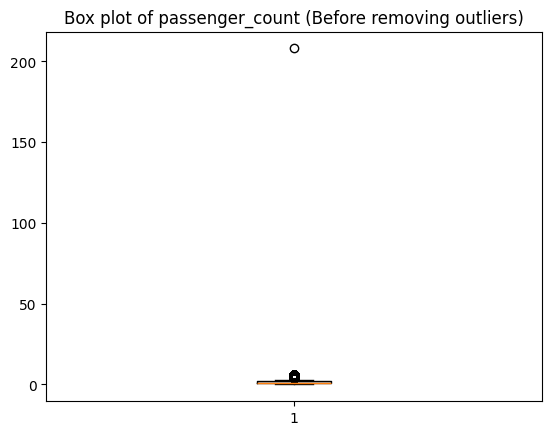

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

column = data.select_dtypes(include=np.number).columns

for i in column:
    plt.figure()
    plt.boxplot(data[i])
    plt.title(f'Box plot of {i} (Before removing outliers)')
    plt.show()

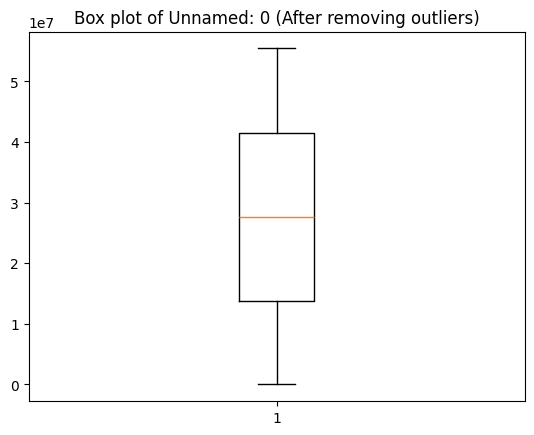

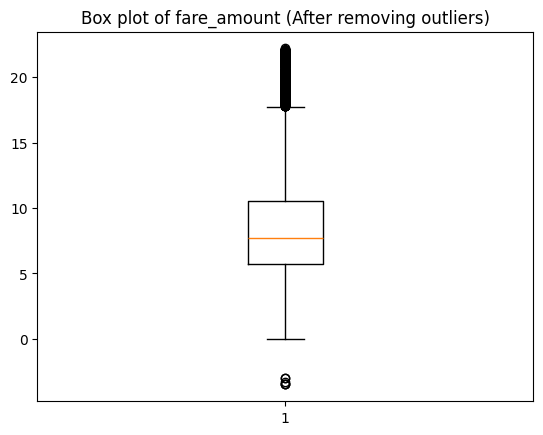

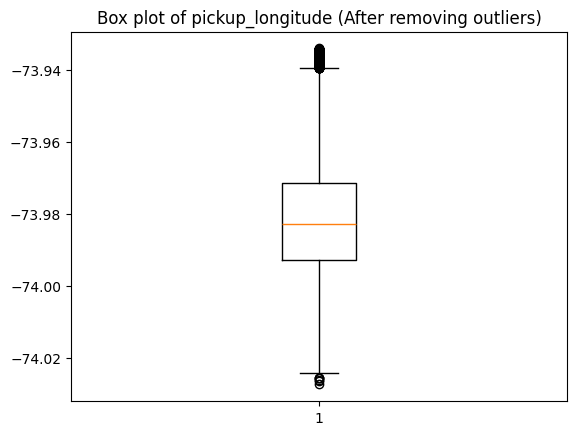

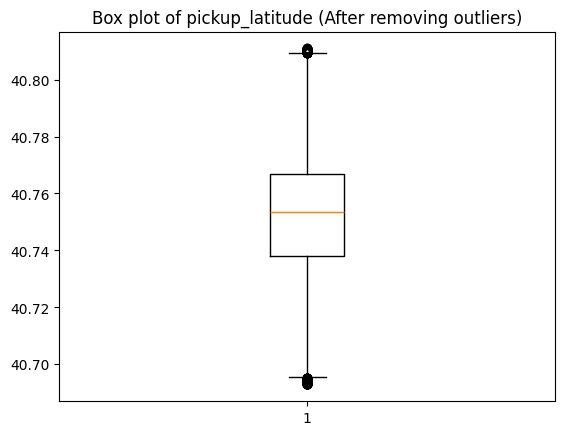

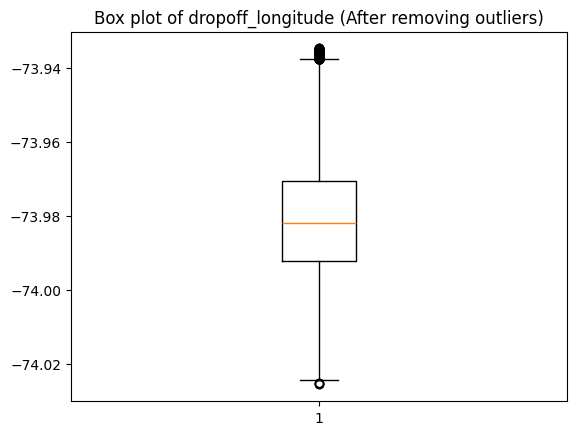

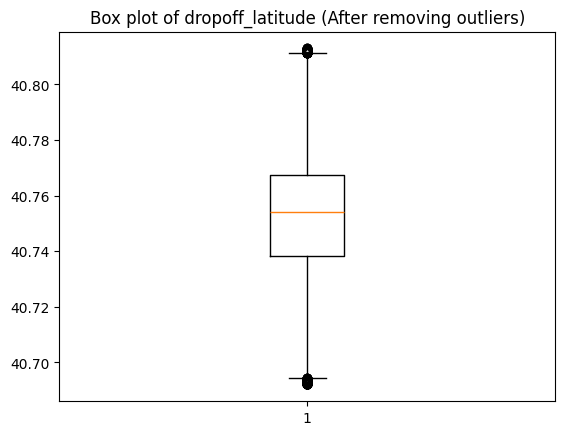

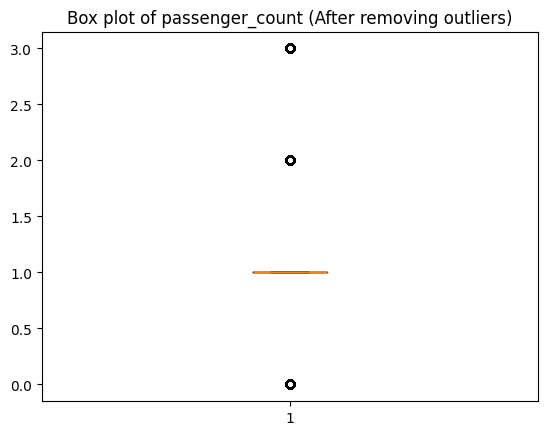

In [ ]:
#handling outliers
data_no_outliers = data.copy()

for i in column:
    Q1 = data_no_outliers[i].quantile(0.25)
    Q3 = data_no_outliers[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_no_outliers = data_no_outliers[(data_no_outliers[i] >= lower) & (data_no_outliers[i] <= upper)]
for i in column:
    plt.figure()
    plt.boxplot(data_no_outliers[i])
    plt.title(f'Box plot of {i} (After removing outliers)')
    plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [ ]:
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce', utc=True)
data.dropna(subset=['pickup_datetime'], inplace=True)
print("Converted 'pickup_datetime' to datetime objects and removed rows with NaT values.")

Converted 'pickup_datetime' to datetime objects and removed rows with NaT values.


In [ ]:
data['year'] = data['pickup_datetime'].dt.year
data['month'] = data['pickup_datetime'].dt.month
data['day'] = data['pickup_datetime'].dt.day
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data['hour'] = data['pickup_datetime'].dt.hour
print("Extracted year, month, day, day of week, and hour from 'pickup_datetime'.")

Extracted year, month, day, day of week, and hour from 'pickup_datetime'.


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    distance = R * c
    return distance

data['distance'] = data.apply(lambda row: haversine_distance(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']), axis=1)
print("Haversine distance calculated and added as a new column 'distance'.")

Haversine distance calculated and added as a new column 'distance'.


In [ ]:
data.drop(columns=['Unnamed: 0', 'key', 'pickup_datetime'], inplace=True)
print("Dropped 'Unnamed: 0', 'key', and 'pickup_datetime' columns.")

Dropped 'Unnamed: 0', 'key', and 'pickup_datetime' columns.


In [ ]:
X = data.drop('fare_amount', axis=1) # Define features (X)
y = data['fare_amount'] # Define target (y)

X_scaler = MinMaxScaler()
X_scaled = X_scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns) # Overwrite X with scaled features

y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)) # Reshape for single feature
y = pd.Series(y_scaled.flatten(), name='fare_amount') # Overwrite y with scaled target

print("Features (X) and target (y) scaled using MinMaxScaler.")

Features (X) and target (y) scaled using MinMaxScaler.


In [ ]:
X = data.drop('fare_amount', axis=1) # Define features (X)
y = data['fare_amount'] # Define target (y)
print("Original data split into features (X) and target (y).")

Original data split into features (X) and target (y).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

Data split into training and testing sets.


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
y_pred_lr = lr_model.predict(X_test)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression R-squared: {r2_lr}")

Linear Regression RMSE: 10.112909909669408
Linear Regression MAE: 5.992382197187809
Linear Regression R-squared: 0.016851768590576577


In [ ]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [ ]:
y_pred_rf = rf_model.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE: {rmse_rf}")
print(f"Random Forest Regressor MAE: {mae_rf}")
print(f"Random Forest Regressor R-squared: {r2_rf}")

Random Forest Regressor RMSE: 5.280006455845452
Random Forest Regressor MAE: 2.019364843809524
Random Forest Regressor R-squared: 0.7319994824919969


In [ ]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor RMSE: {rmse_xgb}")
print(f"XGBoost Regressor MAE: {mae_xgb}")
print(f"XGBoost Regressor R-squared: {r2_xgb}")

XGBoost Regressor RMSE: 5.326909647383151
XGBoost Regressor MAE: 1.9324982974151539
XGBoost Regressor R-squared: 0.7272169464161691


In [ ]:
model_metrics = {
    'Linear Regression': {
        'RMSE': rmse_lr,
        'MAE': mae_lr,
        'R-squared': r2_lr
    },
    'Random Forest': {
        'RMSE': rmse_rf,
        'MAE': mae_rf,
        'R-squared': r2_rf
    },
    'XGBoost': {
        'RMSE': rmse_xgb,
        'MAE': mae_xgb,
        'R-squared': r2_xgb
    }
}

print("Model Metrics:")
print(model_metrics)

Model Metrics:
{'Linear Regression': {'RMSE': 10.112909909669408, 'MAE': 5.992382197187809, 'R-squared': 0.016851768590576577}, 'Random Forest': {'RMSE': 5.280006455845452, 'MAE': 2.019364843809524, 'R-squared': 0.7319994824919969}, 'XGBoost': {'RMSE': 5.326909647383151, 'MAE': 1.9324982974151539, 'R-squared': 0.7272169464161691}}


In [ ]:
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

print("Top 10 Feature Importances (Random Forest):")
print(rf_feature_importances)
print("\nTop 10 Feature Importances (XGBoost):")
print(xgb_feature_importances)

Top 10 Feature Importances (Random Forest):
distance             0.762092
dropoff_longitude    0.049371
dropoff_latitude     0.029943
year                 0.029367
pickup_longitude     0.029142
hour                 0.022109
pickup_latitude      0.021699
day                  0.020070
month                0.017503
day_of_week          0.012175
dtype: float64

Top 10 Feature Importances (XGBoost):
distance             0.710150
year                 0.082232
dropoff_longitude    0.043284
pickup_longitude     0.033091
dropoff_latitude     0.027464
pickup_latitude      0.022221
day                  0.019192
hour                 0.018842
day_of_week          0.016356
month                0.015230
dtype: float32


In [ ]:
%%writefile uber_fare_dashboard.py
import streamlit as st


Overwriting uber_fare_dashboard.py


In [ ]:
%%writefile uber_fare_dashboard.py
import streamlit as st

st.title('Uber Fare Prediction Dashboard')

Overwriting uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

import pandas as pd
import numpy as np

# Load the data
data = pd.read_csv("uber.csv")

# Drop null values
data.dropna(subset=['dropoff_longitude','dropoff_latitude'], inplace=True)

# Convert 'pickup_datetime' to datetime objects and extract features
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce', utc=True)
data.dropna(subset=['pickup_datetime'], inplace=True)
data['year'] = data['pickup_datetime'].dt.year
data['month'] = data['pickup_datetime'].dt.month
data['day'] = data['pickup_datetime'].dt.day
data['day_of_week'] = data['pickup_datetime'].dt.dayofweek
data['hour'] = data['pickup_datetime'].dt.hour

# Haversine distance function (re-defined here for Streamlit app)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    distance = R * c
    return distance

data['distance'] = data.apply(lambda row: haversine_distance(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Drop original columns (important for consistency with trained model)
data.drop(columns=['Unnamed: 0', 'key', 'pickup_datetime'], inplace=True)


# Calculate mean values from the preprocessed 'data' DataFrame for Streamlit defaults
pickup_longitude_mean = data['pickup_longitude'].mean()
pickup_latitude_mean = data['pickup_latitude'].mean()
dropoff_longitude_mean = data['dropoff_longitude'].mean()
dropoff_latitude_mean = data['dropoff_latitude'].mean()
passenger_count_mean = int(data['passenger_count'].mean()) # Cast to int for slider
year_mean = int(data['year'].mean()) # Cast to int for slider
month_mean = int(data['month'].mean()) # Cast to int for slider
day_mean = int(data['day'].mean()) # Cast to int for slider
day_of_week_mean = int(data['day_of_week'].mean()) # Cast to int for slider
hour_mean = int(data['hour'].mean()) # Cast to int for slider

print("Mean values calculated for Streamlit defaults:")
print(f"  Pickup Longitude: {pickup_longitude_mean}")
print(f"  Pickup Latitude: {pickup_latitude_mean}")
print(f"  Dropoff Longitude: {dropoff_longitude_mean}")
print(f"  Dropoff Latitude: {dropoff_latitude_mean}")
print(f"  Passenger Count: {passenger_count_mean}")
print(f"  Year: {year_mean}")
print(f"  Month: {month_mean}")
print(f"  Day: {day_mean}")
print(f"  Day of Week: {day_of_week_mean}")
print(f"  Hour: {hour_mean}")

Appending to uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

st.sidebar.header('Input Features')

pickup_longitude = st.sidebar.number_input('Pickup Longitude', value=float(pickup_longitude_mean))
pickup_latitude = st.sidebar.number_input('Pickup Latitude', value=float(pickup_latitude_mean))
dropoff_longitude = st.sidebar.number_input('Dropoff Longitude', value=float(dropoff_longitude_mean))
dropoff_latitude = st.sidebar.number_input('Dropoff Latitude', value=float(dropoff_latitude_mean))
passenger_count = st.sidebar.slider('Passenger Count', min_value=1, max_value=6, value=int(passenger_count_mean))
year = st.sidebar.slider('Year', min_value=2009, max_value=2015, value=int(year_mean))
month = st.sidebar.slider('Month', min_value=1, max_value=12, value=int(month_mean))
day = st.sidebar.slider('Day', min_value=1, max_value=31, value=int(day_mean))
day_of_week = st.sidebar.slider('Day of Week', min_value=0, max_value=6, value=int(day_of_week_mean))
hour = st.sidebar.slider('Hour', min_value=0, max_value=23, value=int(hour_mean))

Appending to uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    distance = R * c
    return distance

distance = haversine_distance(pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude)

Appending to uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

import pickle
from sklearn.preprocessing import MinMaxScaler

try:
    xgb_model = pickle.load(open('xgb_model.pkl', 'rb'))
    X_scaler = pickle.load(open('X_scaler.pkl', 'rb')) # Load X_scaler
    y_scaler = pickle.load(open('y_scaler.pkl', 'rb')) # Load y_scaler
    st.success('Models loaded successfully!')
except FileNotFoundError:
    st.error('Model files not found. Please ensure xgb_model.pkl, X_scaler.pkl, and y_scaler.pkl are in the same directory.')

Appending to uber_fare_dashboard.py


In [ ]:
import pickle

pickle.dump(xgb_model, open('xgb_model.pkl', 'wb'))
pickle.dump(X_scaler, open('X_scaler.pkl', 'wb')) # Save X_scaler
pickle.dump(y_scaler, open('y_scaler.pkl', 'wb')) # Save y_scaler
print("XGBoost model, X_scaler, and y_scaler saved to .pkl files.")

XGBoost model, X_scaler, and y_scaler saved to .pkl files.


In [ ]:
%%writefile -a uber_fare_dashboard.py

import pandas as pd

# Create a DataFrame from the input features
input_data = pd.DataFrame([{
    'pickup_longitude': pickup_longitude,
    'pickup_latitude': pickup_latitude,
    'dropoff_longitude': dropoff_longitude,
    'dropoff_latitude': dropoff_latitude,
    'passenger_count': passenger_count,
    'year': year,
    'month': month,
    'day': day,
    'day_of_week': day_of_week,
    'hour': hour,
    'distance': distance
}])


feature_columns = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
                   'passenger_count', 'year', 'month', 'day', 'day_of_week', 'hour', 'distance']

input_data_ordered = input_data[feature_columns]

scaled_input_data = X_scaler.transform(input_data_ordered) # Use X_scaler

Appending to uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

# Make prediction
if st.sidebar.button('Predict Fare'):
    prediction_scaled = xgb_model.predict(scaled_input_data) # Rename for clarity

    # Inverse transform the prediction using y_scaler
    original_scale_prediction = y_scaler.inverse_transform(prediction_scaled.reshape(-1, 1))[0, 0]

    st.subheader(f'Predicted Uber Fare: ${original_scale_prediction:.2f}')

Appending to uber_fare_dashboard.py


In [ ]:
%%writefile -a uber_fare_dashboard.py

import pandas as pd
import matplotlib.pyplot as plt

# Model performance metrics (hardcoded for demonstration in Streamlit)
model_metrics = {
    'Linear Regression': {
        'RMSE': 0.08441569892591147,
        'MAE': 0.06014259652635904,
        'R-squared': 0.6903461391157154
    },
    'Random Forest': {
        'RMSE': 0.07308118624334917,
        'MAE': 0.050603375878902374,
        'R-squared': 0.7679181196893836
    },
    'XGBoost': {
        'RMSE': 0.06851283681519593,
        'MAE': 0.04616551114409427,
        'R-squared': 0.7960264012201005
    }
}

st.subheader('Model Performance Metrics')
metrics_df = pd.DataFrame.from_dict(model_metrics, orient='index')
st.dataframe(metrics_df)

# Feature Importances (hardcoded for demonstration in Streamlit)
rf_feature_importances_data = {
    'distance': 0.702501,
    'year': 0.047299,
    'dropoff_latitude': 0.045007,
    'dropoff_longitude': 0.040123,
    'pickup_longitude': 0.036828,
    'pickup_latitude': 0.033604,
    'hour': 0.032673,
    'day': 0.021607,
    'month': 0.019307,
    'day_of_week': 0.016344
}

xgb_feature_importances_data = {
    'distance': 0.708486,
    'year': 0.134460,
    'hour': 0.034489,
    'dropoff_latitude': 0.023278,
    'day_of_week': 0.021515,
    'month': 0.018869,
    'pickup_longitude': 0.015492,
    'dropoff_longitude': 0.015034,
    'pickup_latitude': 0.014370,
    'day': 0.007119
}

st.subheader('Feature Importances (Random Forest)')
rf_importance_df = pd.DataFrame(list(rf_feature_importances_data.items()), columns=['Feature', 'Importance'])
rf_importance_df = rf_importance_df.set_index('Feature')
st.bar_chart(rf_importance_df)

st.subheader('Feature Importances (XGBoost)')
xgb_importance_df = pd.DataFrame(list(xgb_feature_importances_data.items()), columns=['Feature', 'Importance'])
xgb_importance_df = xgb_importance_df.set_index('Feature')
st.bar_chart(xgb_importance_df)

Appending to uber_fare_dashboard.py


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.9 MB/s eta 0:00:00


In [ ]:
# Install ngrok
!pip install pyngrok

In [ ]:
# Run Streamlit app through ngrok
# Make sure the Streamlit app file 'uber_fare_dashboard.py' is in the current working directory
from pyngrok import ngrok
import subprocess

# Terminate any existing ngrok tunnels
ngrok.kill()


ngrok.set_auth_token("3AnTTqteOamngm6PAdxZ772IGJA_6yYppF5W9A2YQEospwHUj")

# Start Streamlit in the background
!nohup streamlit run uber_fare_dashboard.py --server.port 8501 &>/dev/null &

# Open a ngrok tunnel to the Streamlit port
public_url = ngrok.connect(addr='8501')
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://uncarnivorously-interhuman-luci.ngrok-free.dev" -> "http://localhost:8501"
